# 03. Train Model (ALS + Hybrid Recommender)

**Mục tiêu:**
1. Load artifacts từ bước feature engineering (Notebook 02)
2. Train ALS (Collaborative Filtering) trên user-item matrix
3. Lưu model + quick sanity checks (embeddings, score distribution)
4. Test hybrid recommender (CF + basket + popular)

In [19]:
from pathlib import Path
import json

import numpy as np
from scipy.sparse import load_npz

# Setup paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FEATURES_DIR = PROJECT_ROOT / "data" / "03_features"
MODELS_DIR = PROJECT_ROOT / "models"
VIZ_DIR = PROJECT_ROOT / "visualizations" / "03_train_model"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

required_files = [
    FEATURES_DIR / "user_item_matrix.npz",
    FEATURES_DIR / "cf_mappings.json",
    FEATURES_DIR / "cooccurrence_neighbors.json",
    FEATURES_DIR / "popularity.json",
 ]
missing = [p for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Thiếu artifacts từ Notebook 02:\n" + "\n".join([f"- {p}" for p in missing])
    )

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"FEATURES_DIR: {FEATURES_DIR}")
print(f"MODELS_DIR: {MODELS_DIR}")
print(f"VIZ_DIR: {VIZ_DIR}")

PROJECT_ROOT: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender
FEATURES_DIR: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\data\03_features
MODELS_DIR: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\models
VIZ_DIR: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\visualizations\03_train_model


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Load Features (từ Notebook 02)

In [21]:
# Load user-item matrix
user_item_matrix = load_npz(FEATURES_DIR / "user_item_matrix.npz").tocsr()
print(f"user_item_matrix shape: {user_item_matrix.shape}")

# Load mappings (JSON sẽ convert key int -> str)
with open(FEATURES_DIR / "cf_mappings.json", "r", encoding="utf-8") as f:
    cf_maps_raw = json.load(f)

user2idx = {int(k): int(v) for k, v in cf_maps_raw["user2idx"].items()}
prod2idx = {int(k): int(v) for k, v in cf_maps_raw["prod2idx"].items()}
idx2user = {int(k): int(v) for k, v in cf_maps_raw["idx2user"].items()}
idx2prod = {int(k): int(v) for k, v in cf_maps_raw["idx2prod"].items()}

n_users = len(user2idx)
n_products = len(prod2idx)
print(f"Users: {n_users:,}, Products: {n_products:,}")

user_item_matrix shape: (206209, 49677)
Users: 206,209, Products: 49,677


## Train ALS Model (Collaborative Filtering)

In [22]:
# Check dependencies
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)

# Check các thư viện đã có
required_libs = {
    'numpy': 'numpy',
    'scipy': 'scipy',
    'sklearn': 'scikit-learn'
}

missing = []
for name, package in required_libs.items():
    try:
        __import__(name)
        print(f"✓ {package} đã có sẵn")
    except ImportError:
        missing.append(package)
        print(f"✗ {package} chưa có")

if missing:
    print(f"\n⚠ Thiếu: {', '.join(missing)}")
    print("Cài đặt...")
    import subprocess
    for pkg in missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
    print("✓ Đã cài xong các thư viện cần thiết!")
else:
    print("\n Tất cả dependencies đã sẵn sàng!")

Python executable: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\.venv\Scripts\python.exe
Python version: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
✓ numpy đã có sẵn
✓ scipy đã có sẵn
✓ scikit-learn đã có sẵn

 Tất cả dependencies đã sẵn sàng!


In [23]:
# Dùng scikit-learn's NMF thay cho implicit (không cần compiler)
from sklearn.decomposition import NMF
import numpy as np

# Normalize user-item matrix
from scipy.sparse import csr_matrix

print(f"Original user-item matrix: {user_item_matrix.shape}")
print(f"Matrix type: {type(user_item_matrix)}")
print(f"Non-zero entries: {user_item_matrix.nnz:,}")

# Convert to dense for NMF (nếu matrix không quá lớn)
if user_item_matrix.shape[0] * user_item_matrix.shape[1] > 10_000_000:
    print("⚠ Matrix quá lớn, sẽ sample để demo...")
    # Giữ top users với nhiều interactions nhất
    user_activity = np.array(user_item_matrix.sum(axis=1)).flatten()
    top_users_idx = np.argsort(user_activity)[::-1][:1000]
    user_item_matrix_dense = user_item_matrix[top_users_idx].toarray()
    print(f"Sampled matrix: {user_item_matrix_dense.shape}")
else:
    user_item_matrix_dense = user_item_matrix.toarray()
    print(f"Dense matrix: {user_item_matrix_dense.shape}")

print(f"\n✓ Sẵn sàng training NMF với {user_item_matrix_dense.shape[0]:,} users × {user_item_matrix_dense.shape[1]:,} items")

Original user-item matrix: (206209, 49677)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Non-zero entries: 13,307,953
⚠ Matrix quá lớn, sẽ sample để demo...
Sampled matrix: (1000, 49677)

✓ Sẵn sàng training NMF với 1,000 users × 49,677 items


In [24]:
# Train NMF (Non-negative Matrix Factorization)
# Tương tự ALS nhưng không cần C++ compiler
model = NMF(
    n_components=64,
    init='nndsvda',
    max_iter=200,
    random_state=42,
    verbose=1
)

print("Đang training NMF...")
user_factors = model.fit_transform(user_item_matrix_dense)
item_factors = model.components_.T

print(f"\n✓ Training hoàn tất!")
print(f"User factors shape: {user_factors.shape}")
print(f"Item factors shape: {item_factors.shape}")

Đang training NMF...
violation: 1.0
violation: 0.2630940899466226
violation: 0.2912072120654585
violation: 0.2626727365252063
violation: 0.2532052944381653
violation: 0.2425107537928811
violation: 0.21957354074133856
violation: 0.1817797766182809
violation: 0.14953969983784995
violation: 0.1218954314749006
violation: 0.09928569641121122
violation: 0.08204420765390374
violation: 0.0688425404122781
violation: 0.05825206970071869
violation: 0.051469998432507616
violation: 0.04672778327570203
violation: 0.04376765533613079
violation: 0.04183521317910905
violation: 0.03864853551058835
violation: 0.033861500800851534
violation: 0.028815414687311258
violation: 0.024678633643570855
violation: 0.021146702637323267
violation: 0.01856672203875558
violation: 0.016567132097308535
violation: 0.014931289156145614
violation: 0.013649240141364248
violation: 0.012629058150659442
violation: 0.011906683885828195
violation: 0.011286585891226976
violation: 0.010537288349542562
violation: 0.01011486813790757

In [25]:
# Save model
import pickle

model_data = {
    'model': model,
    'user_factors': user_factors,
    'item_factors': item_factors,
    'user_item_matrix_shape': user_item_matrix.shape
}

model_path = MODELS_DIR / "nmf_model.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(model_data, f)
    
print(f"✓ Model saved: {model_path}")

✓ Model saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\models\nmf_model.pkl


## Quick Sanity Checks & Visualizations

In [26]:
print(f"User factors shape: {user_factors.shape}")
print(f"Item factors shape: {item_factors.shape}")

user_norms = np.linalg.norm(user_factors, axis=1)
item_norms = np.linalg.norm(item_factors, axis=1)
print(f"User norms: mean={user_norms.mean():.2f}, std={user_norms.std():.2f}, min={user_norms.min():.2f}, max={user_norms.max():.2f}")
print(f"Item norms: mean={item_norms.mean():.2f}, std={item_norms.std():.2f}, min={item_norms.min():.2f}, max={item_norms.max():.2f}")

User factors shape: (1000, 64)
Item factors shape: (49677, 64)
User norms: mean=1.04, std=0.94, min=0.13, max=10.12
Item norms: mean=1.69, std=19.41, min=0.00, max=3256.40


Testing CF recommendation for user_idx=0, user_id=1


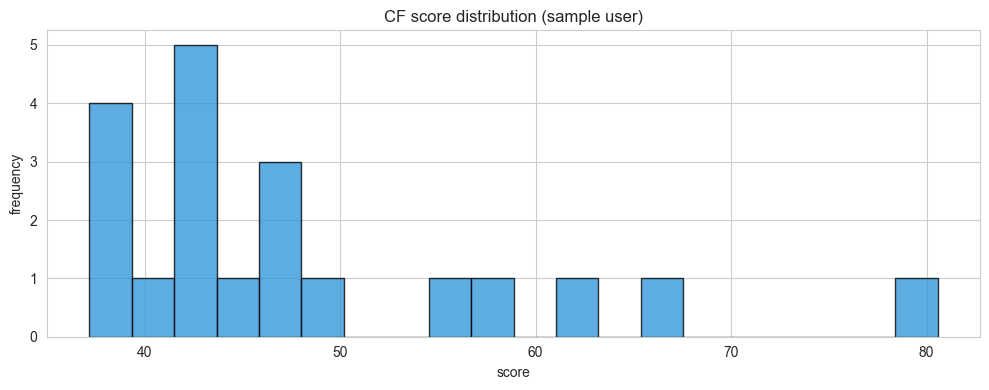

✓ Saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\visualizations\03_train_model\01_cf_score_distribution.png


In [27]:
# Sample score distribution (CF with NMF)
test_user_idx = 0
test_user_id = idx2user.get(test_user_idx, None)
print(f"Testing CF recommendation for user_idx={test_user_idx}, user_id={test_user_id}")

# Compute recommendations: user_factors @ item_factors.T
if test_user_idx < user_factors.shape[0]:
    user_vec = user_factors[test_user_idx]
    scores_all = user_vec @ item_factors.T
    
    # Filter already liked items
    already_liked = user_item_matrix[test_user_idx].toarray().flatten()
    scores_all[already_liked > 0] = -np.inf
    
    # Get top N
    top_indices = np.argsort(scores_all)[::-1][:20]
    scores_cf = scores_all[top_indices]
    
    plt.figure(figsize=(10, 4))
    plt.hist(scores_cf, bins=20, color="#3498db", edgecolor="black", alpha=0.8)
    plt.title("CF score distribution (sample user)")
    plt.xlabel("score")
    plt.ylabel("frequency")
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "01_cf_score_distribution.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved: {VIZ_DIR / '01_cf_score_distribution.png'}")
else:
    print(f"⚠ test_user_idx={test_user_idx} nằm ngoài phạm vi sampled users")

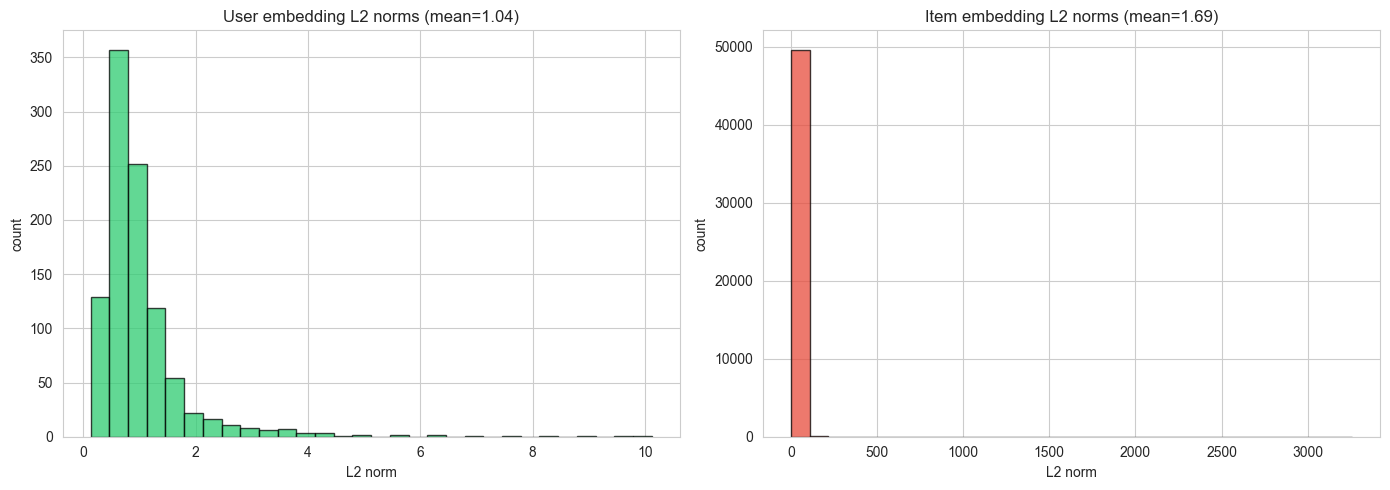

✓ Saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\visualizations\03_train_model\02_embedding_norms.png


In [28]:
# Visualization: embedding norms
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(user_norms, bins=30, color="#2ecc71", edgecolor="black", alpha=0.75)
ax[0].set_title(f"User embedding L2 norms (mean={user_norms.mean():.2f})")
ax[0].set_xlabel("L2 norm")
ax[0].set_ylabel("count")

ax[1].hist(item_norms, bins=30, color="#e74c3c", edgecolor="black", alpha=0.75)
ax[1].set_title(f"Item embedding L2 norms (mean={item_norms.mean():.2f})")
ax[1].set_xlabel("L2 norm")
ax[1].set_ylabel("count")

plt.tight_layout()
plt.savefig(VIZ_DIR / "02_embedding_norms.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {VIZ_DIR / '02_embedding_norms.png'}")

## Load Basket + Popularity (cho Hybrid)

In [29]:
# Load basket neighbors (co-occurrence)
with open(FEATURES_DIR / "cooccurrence_neighbors.json", "r", encoding="utf-8") as f:
    basket_neighbors_raw = json.load(f)

# keys: str -> int, values: list[[prod, cnt], ...]
basket_neighbors = {
    int(prod_id): [(int(p), int(cnt)) for p, cnt in neigh]
    for prod_id, neigh in basket_neighbors_raw.items()
}

# Load popularity
with open(FEATURES_DIR / "popularity.json", "r", encoding="utf-8") as f:
    popularity = json.load(f)

pop_global = [(int(pid), int(cnt)) for pid, cnt in popularity["global"]]
pop_max = max([cnt for _, cnt in pop_global]) if pop_global else 1

print(f"Loaded basket neighbors for {len(basket_neighbors):,} products")
print(f"Global popular items: {len(pop_global):,} (max_count={pop_max:,})")

Loaded basket neighbors for 49,674 products
Global popular items: 200 (max_count=472,565)


In [30]:
def hybrid_recommend(user_id, cart_items=None, n=10, w_cf=0.6, w_basket=0.25, w_pop=0.15):
    """Hybrid recommender kết hợp 3 nguồn: CF (NMF) + basket (co-occurrence) + popularity.
    - user_id: int
    - cart_items: list[int] | None
    """
    candidates = {}  # product_id -> score
    cart_items = [int(x) for x in cart_items] if cart_items else []
    cart_set = set(cart_items)

    # 1) CF recommendations (NMF-based)
    if user_id in user2idx:
        user_idx = user2idx[user_id]
        if user_idx < user_factors.shape[0]:
            # Compute scores
            user_vec = user_factors[user_idx]
            scores_all = user_vec @ item_factors.T
            
            # Filter already liked
            already_liked = user_item_matrix[user_idx].toarray().flatten()
            scores_all[already_liked > 0] = -np.inf
            
            # Get top candidates
            top_indices = np.argsort(scores_all)[::-1][:200]
            for item_idx in top_indices:
                if scores_all[item_idx] == -np.inf:
                    continue
                prod_id = idx2prod[int(item_idx)]
                if prod_id in cart_set:
                    continue
                # Normalize score to 0-1 range
                score = float(scores_all[item_idx])
                if score > 0:
                    candidates[prod_id] = candidates.get(prod_id, 0.0) + w_cf * score

    # 2) Basket recommendations (từ cart)
    if cart_items:
        for cart_prod in cart_items:
            neigh = basket_neighbors.get(cart_prod, [])
            for neighbor_prod, co_count in neigh[:50]:
                if neighbor_prod in cart_set:
                    continue
                # score: log scale (0..~)
                score_basket = float(np.log1p(co_count))
                candidates[neighbor_prod] = candidates.get(neighbor_prod, 0.0) + w_basket * score_basket

    # 3) Popular fallback
    for prod_id, count in pop_global[:200]:
        if prod_id in cart_set:
            continue
        # normalize to 0..1
        score_pop = float(count) / float(pop_max)
        candidates[prod_id] = candidates.get(prod_id, 0.0) + w_pop * score_pop

    ranked = sorted(candidates.items(), key=lambda x: x[1], reverse=True)
    return ranked[:n]

## Test Hybrid Recommender

In [31]:
# Test 1: chỉ user_id, không có cart
test_user_idx = 0
test_user_id = idx2user.get(test_user_idx, None)
if test_user_id is None:
    raise ValueError("Không tìm thấy user_id cho user_idx=0 (idx2user)")

print(f"=== Test 1: Hybrid recommend for user_id={test_user_id} (no cart) ===")
recs1 = hybrid_recommend(user_id=test_user_id, cart_items=None, n=10)
for prod_id, score in recs1:
    print(f"  product_id={prod_id}, hybrid_score={score:.4f}")

=== Test 1: Hybrid recommend for user_id=1 (no cart) ===
  product_id=27344, hybrid_score=48.3524
  product_id=27521, hybrid_score=40.2966
  product_id=44632, hybrid_score=37.8730
  product_id=21709, hybrid_score=34.7091
  product_id=40604, hybrid_score=33.9001
  product_id=33401, hybrid_score=29.1613
  product_id=42828, hybrid_score=28.4190
  product_id=9550, hybrid_score=27.9065
  product_id=4799, hybrid_score=27.5722
  product_id=29926, hybrid_score=26.5939


In [32]:
# Test 2: có cart_items
cart_items = [24852, 13176, 21137]  # ví dụ 3 sản phẩm trong giỏ
print(f"\n=== Test 2: Hybrid recommend for user_id={test_user_id} with cart={cart_items} ===")
recs2 = hybrid_recommend(user_id=test_user_id, cart_items=cart_items, n=10)
for prod_id, score in recs2:
    print(f"  product_id={prod_id}, hybrid_score={score:.4f}")


=== Test 2: Hybrid recommend for user_id=1 with cart=[24852, 13176, 21137] ===
  product_id=27344, hybrid_score=48.3524
  product_id=44632, hybrid_score=42.5392
  product_id=27521, hybrid_score=40.2966
  product_id=21709, hybrid_score=34.7091
  product_id=40604, hybrid_score=33.9001
  product_id=30489, hybrid_score=32.9490
  product_id=33401, hybrid_score=29.1613
  product_id=42828, hybrid_score=28.4190
  product_id=5876, hybrid_score=27.9317
  product_id=9550, hybrid_score=27.9065


Sử dụng test_user_id đã có: 1


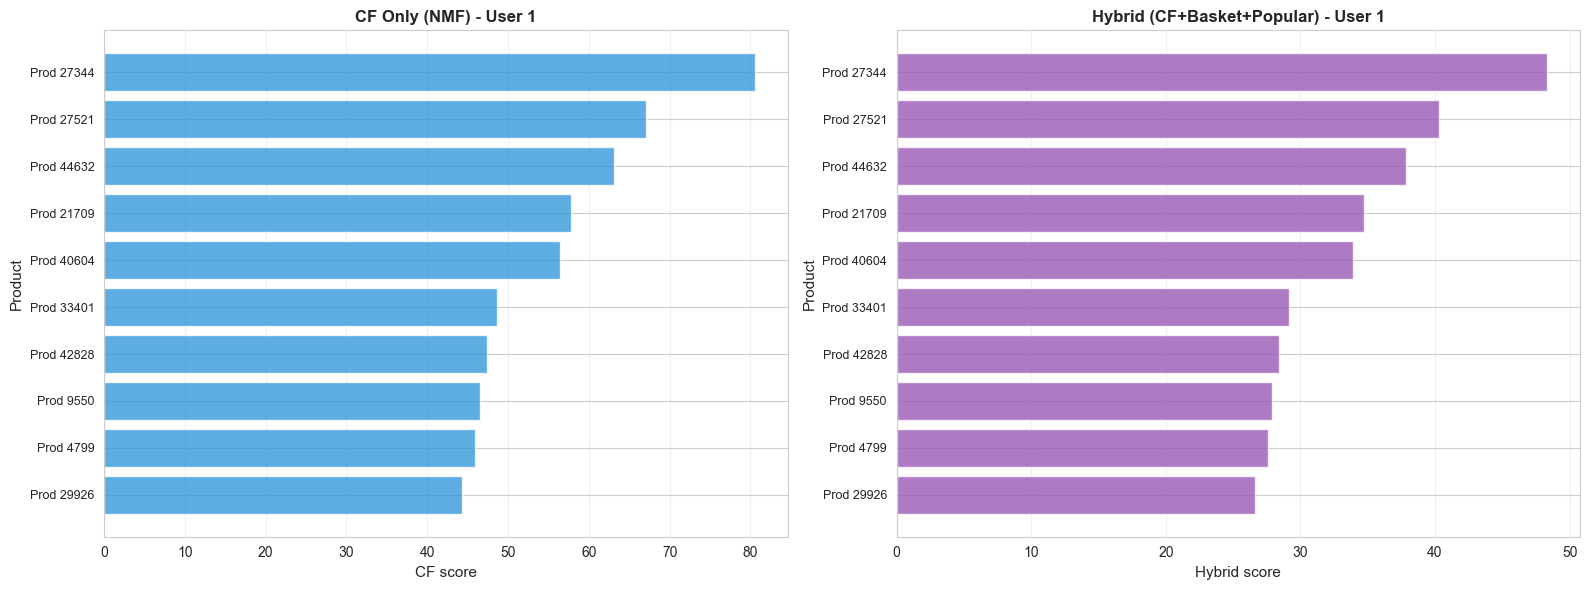

✓ Saved: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\visualizations\03_train_model\03_hybrid_vs_cf.png

 Phân tích:
  - Overlap CF vs Hybrid: 10/10 products
  - CF unique: 0 products
  - Hybrid unique: 0 products


In [33]:
# Visualization: Hybrid vs CF comparison
# Đảm bảo an toàn khi chạy độc lập cell này

# Kiểm tra và lấy test_user_id (tránh warning từ linter)
_test_user_id = locals().get('test_user_id', None)

if _test_user_id is None:
    # Nếu chưa có, lấy user đầu tiên
    _test_user_id = idx2user.get(0, None)
    print(f"Khởi tạo test_user_id mới: {_test_user_id}")
else:
    print(f"Sử dụng test_user_id đã có: {_test_user_id}")

# Validate test_user_id
if _test_user_id is None:
    raise ValueError("Không tìm thấy test_user_id. Hãy chạy cell 'Test 1: Hybrid recommend' trước hoặc kiểm tra idx2user.")
if _test_user_id not in user2idx:
    raise KeyError(f"user_id={_test_user_id} không có trong user2idx (cold-start user?)")

# Lấy recommendations từ CF (NMF)
user_idx_compare = user2idx[_test_user_id]
if user_idx_compare < user_factors.shape[0]:
    user_vec = user_factors[user_idx_compare]
    scores_all_cf = user_vec @ item_factors.T
    already_liked = user_item_matrix[user_idx_compare].toarray().flatten()
    scores_all_cf[already_liked > 0] = -np.inf
    top_cf_indices = np.argsort(scores_all_cf)[::-1][:10]
    
    prod_ids_cf = [idx2prod[int(idx)] for idx in top_cf_indices]
    scores_cf = [float(scores_all_cf[idx]) for idx in top_cf_indices]
else:
    print(f" User {_test_user_id} không có trong sampled users, dùng popular items")
    prod_ids_cf = [pid for pid, _ in pop_global[:10]]
    scores_cf = [1.0] * len(prod_ids_cf)

# Lấy recommendations từ Hybrid
recs_hybrid_compare = hybrid_recommend(user_id=_test_user_id, cart_items=None, n=10)
prod_ids_hybrid = [pid for pid, _ in recs_hybrid_compare]
scores_hybrid = [float(score) for _, score in recs_hybrid_compare]

# Tạo visualization so sánh
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# CF Only
ax[0].barh(range(len(prod_ids_cf)), scores_cf[::-1], color="#3498db", alpha=0.8)
ax[0].set_yticks(range(len(prod_ids_cf)))
ax[0].set_yticklabels([f"Prod {pid}" for pid in prod_ids_cf[::-1]], fontsize=9)
ax[0].set_xlabel("CF score", fontsize=11)
ax[0].set_ylabel("Product", fontsize=11)
ax[0].set_title(f"CF Only (NMF) - User {_test_user_id}", fontsize=12, fontweight="bold")
ax[0].grid(axis='x', alpha=0.3)

# Hybrid
ax[1].barh(range(len(prod_ids_hybrid)), scores_hybrid[::-1], color="#9b59b6", alpha=0.8)
ax[1].set_yticks(range(len(prod_ids_hybrid)))
ax[1].set_yticklabels([f"Prod {pid}" for pid in prod_ids_hybrid[::-1]], fontsize=9)
ax[1].set_xlabel("Hybrid score", fontsize=11)
ax[1].set_ylabel("Product", fontsize=11)
ax[1].set_title(f"Hybrid (CF+Basket+Popular) - User {_test_user_id}", fontsize=12, fontweight="bold")
ax[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(VIZ_DIR / "03_hybrid_vs_cf.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {VIZ_DIR / '03_hybrid_vs_cf.png'}")

# Phân tích overlap
overlap = set(prod_ids_cf) & set(prod_ids_hybrid)
print(f"\n Phân tích:")
print(f"  - Overlap CF vs Hybrid: {len(overlap)}/10 products")
print(f"  - CF unique: {len(set(prod_ids_cf) - set(prod_ids_hybrid))} products")
print(f"  - Hybrid unique: {len(set(prod_ids_hybrid) - set(prod_ids_cf))} products")

In [34]:
print("\n Training & Testing hoàn tất!")
print(f"Model đã lưu tại: {model_path}")
print(f"Visualizations: {VIZ_DIR}")


 Training & Testing hoàn tất!
Model đã lưu tại: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\models\nmf_model.pkl
Visualizations: e:\Nam3\TailLieuHocKi7\WEB2\VuaVuiVeNC\VuaVuiVe_Recommender\visualizations\03_train_model
